# UASD 

## Initialization

Zorg ervoor dat je alle packages hebt gedownload, de meeste kan je downloaden via de volgende command:

`pip install torch torchaudio scikit-learn`

zorg er ook voor dat je de unilm/beats repo cloned voor het BEATs model. Clonen kan via https://github.com/microsoft/unilm/tree/master/beats. Zorg ook dat je `BEATs_iter3_plus_AS2M.pt` hebt download via de README in de unilm/beats repo.

zorg ervoor dat je je data op de juiste manier opslaat, volg hiervoor de volgende directory structure:

```text
data/
└── dcase2025t2/
    ├── dev_data/
    │   ├── processed/
    │   └── raw/
    │       └── {machine}/
    │           ├── test/
    │           ├── train/
    │           └── attributes_00.csv
    └── eval_data/
        ├── processed/
        └── raw/
            └── {machine}/
```

Hetzelfde geldt voor het opslaan van de features:

```text
features/
└── EAT/
    └── dcase2025t2_features/
        └── dev_features/
            └── raw_features/
                └── {machine}_features/
                    ├── train_features/    
                    ├── test_features/      
                    └── pca/                
                        ├── train_features_pca.npy
                        ├── test_features_pca.npy
                        └── pca_model.pkl
└── BEATs/
    └── dcase2025t2_features/
        └── dev_features/
            └── raw_features/
                └── {machine}_features/
                    ├── train_features/    
                    ├── test_features/      
                    └── pca/                
                        ├── train_features_pca.npy
                        ├── test_features_pca.npy
                        └── pca_model.pkl
```


In [ ]:
import os
import sys
import torch
import torchaudio
import numpy as np
import transformers
from scipy.io import wavfile
import torch.nn as nn
from transformers import AutoModel, AutoProcessor

sys.path.insert(0, r"c:\Users\lucth\Downloads\Sorama Internship\EAT")

c:\Users\20202299\AppData\Local\anaconda3\envs\sorama\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load EAT

In [2]:
# 1. Configuration
MODEL_NAME = "worstchan/EAT-base_epoch30_pretrain"
_PATCH_FLAG = "_eat_compat_patched"

# 2. Corrected Patching Logic
# We use getattr() to avoid the KeyError if the internal method doesn't exist
if not getattr(transformers.PreTrainedModel, _PATCH_FLAG, False):
    # Safely look for the internal method
    _orig_adjust = getattr(transformers.PreTrainedModel, "_adjust_tied_keys_with_tied_pointers", None)

    if _orig_adjust is not None:
        def _eat_adjust(self, missing_keys):
            # Ensure 'all_tied_weights_keys' is a dict as expected by transformers
            v = getattr(self, "all_tied_weights_keys", None)
            if not isinstance(v, dict):
                self.all_tied_weights_keys = {}
            return _orig_adjust(self, missing_keys)

        # Apply the override
        transformers.PreTrainedModel._adjust_tied_keys_with_tied_pointers = _eat_adjust
        setattr(transformers.PreTrainedModel, _PATCH_FLAG, True)
        print("Successfully applied the compatibility patch.")
    else:
        print("Patch skipped: Target method not found in this transformers version.")
else:
    print("Patch was already active.")

# 3. Model Loading
try:
    print(f"Loading model: {MODEL_NAME}...")
    eat_model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)
    eat_model.eval()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    eat_model.to(device)

    print(f"Model loaded successfully on: {device}")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Tip: Ensure you have 'pip install torchaudio soundfile' installed.")

Patch skipped: Target method not found in this transformers version.
Loading model: worstchan/EAT-base_epoch30_pretrain...
Model loaded successfully on: cpu


In [6]:
TARGET_LENGTH = 512   # aantal frames in de tijdas
NORM_MEAN = -4.268    # gemiddelde voor normalisatie (van EAT training)
NORM_STD = 4.569      # standaarddeviatie voor normalisatie

def wav_to_mel(wav_path, target_length=TARGET_LENGTH):
    """Laad een wav-bestand en zet het om naar een mel spectrogram."""
    waveform, sr = torchaudio.load(wav_path)

    # Omzetten naar mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample naar 16kHz (wat EAT verwacht)
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    # Bereken Kaldi fbank mel spectrogram (128 kanalen)
    fbank = torchaudio.compliance.kaldi.fbank(
        waveform,
        htk_compat=True,
        sample_frequency=16000,
        use_energy=False,
        window_type='hanning',
        num_mel_bins=128,
        dither=0.0,
        frame_shift=10
    )  # vorm: [T, 128]

    # Pad of trim naar vaste lengte
    T = fbank.shape[0]
    if T < target_length:
        fbank = torch.nn.functional.pad(fbank, (0, 0, 0, target_length - T))
    else:
        fbank = fbank[:target_length, :]

 # Normaliseer
    fbank = (fbank - NORM_MEAN) / (NORM_STD * 2)

    # Voeg batch- en kanaal-dimensie toe: [1, 1, T, 128]
    return fbank.unsqueeze(0).unsqueeze(0)


def extract_eat_embedding(wav_path):
    """Geeft een 768-dimensionale embedding terug voor een wav-bestand."""
    mel = wav_to_mel(wav_path).to(device)
    with torch.no_grad():
        # De HuggingFace EATModel.extract_features() accepteert alleen x (geen padding_mask)
        # en geeft een tensor terug van vorm [B, T, 768].
        # We pakken het CLS-token (positie 0) als representatie voor het hele clip.
        out = eat_model.extract_features(mel)  # vorm: [1, T, 768]
        embedding = out[:, 0, :].squeeze(0).cpu().numpy()  # [768]
    return embedding

## Extracting Features (6 min per machine)

In [8]:
from config import iter_all_data, get_features_path, get_train_features_path, get_test_features_path

model_used = "EAT"

# Process all machines across all years
for year, machine, input_folder in iter_all_data():
    output_folder = get_features_path(model_used, year, machine, dataset="dev")
    print(f"\n Processing {year} - {machine}")
    print(f"Input:  {input_folder}")
    print(f"Output: {output_folder}")

    # ========== TRAIN FEATURES ==========
    train_input = input_folder / "train"
    if train_input.exists():
        train_output = get_train_features_path(model_used, year, machine, dataset="dev")
        
        # Check if train extraction is already done (>=1000 files)
        existing_train = list(train_output.rglob("*.npy"))
        if len(existing_train) >= 1000:
            print(f"Skipping train - {len(existing_train)} train features already present")
        else:
            # Count files first
            train_wav_files = list(train_input.glob("**/*.wav"))
            if not train_wav_files:
                print(f"No train .wav files found")
            else:
                print(f"Processing train: Found {len(train_wav_files)} audio files")

                # Process each file
                train_processed = 0
                for wav_file in train_wav_files:
                    try:
                        # Load and process audio
                        embedding = extract_eat_embedding(str(wav_file))
                        # Create output path (mirror input structure)
                        relative_path = wav_file.relative_to(train_input)
                        out_file = train_output / relative_path.with_suffix('.npy')
                        out_file.parent.mkdir(parents=True, exist_ok=True)

                        # Save embedding
                        np.save(out_file, embedding)
                        train_processed += 1

                    except Exception as e:
                        print(f"Error processing {wav_file}: {e}")

                print(f"Processed {train_processed}/{len(train_wav_files)} train files")
    else:
        print(f"No train folder found")

    # ========== TEST FEATURES ==========
    test_input = input_folder / "test"
    if test_input.exists():
        test_output = get_test_features_path(model_used, year, machine, dataset="dev")
        
        # Check if test extraction is already done (>=200 files)
        existing_test = list(test_output.rglob("*.npy"))
        if len(existing_test) >= 200:
            print(f"Skipping test - {len(existing_test)} test features already present")
        else:
            # Count files first
            test_wav_files = list(test_input.glob("**/*.wav"))
            if not test_wav_files:
                print(f"No test .wav files found")
            else:
                print(f"Processing test: Found {len(test_wav_files)} audio files")

                # Process each file
                test_processed = 0
                for wav_file in test_wav_files:
                    try:
                        # Load and process audio
                        embedding = extract_eat_embedding(str(wav_file))

                        # Create output path (mirror input structure)
                        relative_path = wav_file.relative_to(test_input)
                        out_file = test_output / relative_path.with_suffix('.npy')
                        out_file.parent.mkdir(parents=True, exist_ok=True)

                        # Save embedding
                        np.save(out_file, embedding)
                        test_processed += 1

                    except Exception as e:
                        print(f"Error processing {wav_file}: {e}")

                print(f"Processed {test_processed}/{len(test_wav_files)} test files")
    else:
        print(f"No test folder found")

print("\n All feature extraction completed")


 Processing dcase2023t2 - ToyCar
Input:  c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data\dcase2023t2\dev_data\raw\ToyCar
Output: c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\features\EAT\dcase2023t2_features\dev_features\raw_features\ToyCar_features
Processing train: Found 1000 audio files
Processed 1000/1000 train files
Processing test: Found 200 audio files
Processed 200/200 test files

 Processing dcase2023t2 - ToyTrain
Input:  c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data\dcase2023t2\dev_data\raw\ToyTrain
Output: c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\features\EAT\dcase2023t2_features\dev_features\raw_features\ToyTrain_features
Processing train: Found 1000 audio files


KeyboardInterrupt: 

## PCA 

Let op! Als er al een pca.pkl file bestaat dan wordt die machine geskipt, dit zorgt ervoor dat er soms machines worden geskipt omdat er een pca.pkl file bestaat die was aangemaakt toen nog niet alle features waren geextraheerd, zorg er dan voor dat je de hele PCA folder verwijderd van die machine. 

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from config import iter_all_data, get_features_path, get_train_features_path, get_test_features_path, get_pca_path
import pickle
import os
            
# Function to apply PCA to a single machine's features
def apply_pca_to_machine(year, machine, features_path):
    """Apply PCA to features of a specific machine and save results"""

    # Define the output directory and the "flag" file
    pca_dir = get_pca_path(model_used, year, machine, dataset="dev")
    flag_file = pca_dir / "pca_model.pkl"

    if flag_file.exists():
        print(f"Skipping {year}-{machine}: PCA results already exist.")
        # Optional: Load and return the existing data if you still need it in pca_results{}
        # X_train_pca = np.load(pca_dir / "train_features_pca.npy")
        # with open(flag_file, 'rb') as f:
        #     pca_reduced = pickle.load(f)
        # return X_train_pca, pca_reduced
        return None, "exists" 

    # Load training features (for fitting PCA)
    train_features_path = get_train_features_path(model_used, year, machine, dataset="dev")
    if not train_features_path.exists():
        print(f"No train features found for {year}-{machine}")
        return None, None

    train_files = list(train_features_path.glob("**/*.npy"))
    if not train_files:
        print(f"No train feature files found for {year}-{machine}")
        return None, None

    print(f"Processing {len(train_files)} train features for {year}-{machine}")

    # Load train embeddings
    train_embeddings = []
    for file in train_files:
        try:
            emb = np.load(file)
            train_embeddings.append(emb)
        except Exception as e:
            print(f"Error loading train {file}: {e}")

    if not train_embeddings:
        print(f"No valid train embeddings for {year}-{machine}")
        return None, None

    X_train = np.vstack(train_embeddings)
    print(f"   Train shape: {X_train.shape}")

    # 1. Full PCA for variance analysis (on train data)
    pca_full = PCA()
    pca_full.fit(X_train)

    # 2. Apply PCA with 95% variance threshold (trained on train data)
    pca_reduced = PCA(n_components=0.95)
    X_train_pca = pca_reduced.fit_transform(X_train)

    print(f"   Train PCA shape: {X_train_pca.shape} (components: {pca_reduced.n_components_})")

    # 3. Apply trained PCA to test features if they exist
    test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
    X_test_pca = None
    if test_features_path.exists():
        test_files = list(test_features_path.glob("**/*.npy"))
        if test_files:
            test_embeddings = []
            for file in test_files:
                try:
                    emb = np.load(file)
                    test_embeddings.append(emb)
                except Exception as e:
                    print(f"Error loading test {file}: {e}")

            if test_embeddings:
                X_test = np.vstack(test_embeddings)
                X_test_pca = pca_reduced.transform(X_test)
                print(f"   Test PCA shape: {X_test_pca.shape}")

    # 4. Save PCA results
    pca_dir = get_pca_path(model_used, year, machine, dataset="dev")

    # Save train features
    np.save(pca_dir / "train_features_pca.npy", X_train_pca)

    # Save test features if available
    if X_test_pca is not None:
        np.save(pca_dir / "test_features_pca.npy", X_test_pca)

    # Save PCA model for future use
    with open(pca_dir / "pca_model.pkl", 'wb') as f:
        pickle.dump(pca_reduced, f)

    # Save explained variance info
    variance_info = {
        'explained_variance_ratio': pca_reduced.explained_variance_ratio_,
        'cumulative_variance': np.cumsum(pca_reduced.explained_variance_ratio_),
        'n_components': pca_reduced.n_components_,
        'train_original_shape': X_train.shape,
        'train_reduced_shape': X_train_pca.shape,
        'test_reduced_shape': X_test_pca.shape if X_test_pca is not None else None
    }
    np.save(pca_dir / "variance_info.npy", variance_info)

    return X_train_pca, pca_reduced

# Process all machines
print("Starting PCA processing for all machines...\n")

pca_results = {}
for year, machine, _ in iter_all_data():
    features_path = get_features_path(model_used, year, machine, dataset="dev")

    if not features_path.exists():
        print(f"Features directory not found: {features_path}")
        continue

    print(f"\n Processing {year} - {machine}")
    X_pca, pca_model = apply_pca_to_machine(year, machine, features_path)

    if X_pca is not None:
        pca_results[f"{year}_{machine}"] = {
            'features': X_pca,
            'model': pca_model,
            'path': features_path
        }

print(f"\n PCA completed for {len(pca_results)} machines")
print("PCA results saved in each machine's features/pca/ directory")

Starting PCA processing for all machines...


 Processing dcase2023t2 - ToyCar
Processing 1000 train features for dcase2023t2-ToyCar
   Train shape: (1000, 768)
   Train PCA shape: (1000, 33) (components: 33)
   Test PCA shape: (200, 33)

 Processing dcase2023t2 - ToyTrain
Processing 12 train features for dcase2023t2-ToyTrain
   Train shape: (12, 768)
   Train PCA shape: (12, 8) (components: 8)

 Processing dcase2023t2 - bearing
Processing 1000 train features for dcase2023t2-bearing
   Train shape: (1000, 768)
   Train PCA shape: (1000, 36) (components: 36)
   Test PCA shape: (200, 36)

 Processing dcase2023t2 - fan
No train feature files found for dcase2023t2-fan

 Processing dcase2023t2 - gearbox
No train feature files found for dcase2023t2-gearbox

 Processing dcase2023t2 - valve
No train feature files found for dcase2023t2-valve

 Processing dcase2024t2 - ToyCar
No train feature files found for dcase2024t2-ToyCar

 Processing dcase2024t2 - ToyTrain
No train feature files found for 

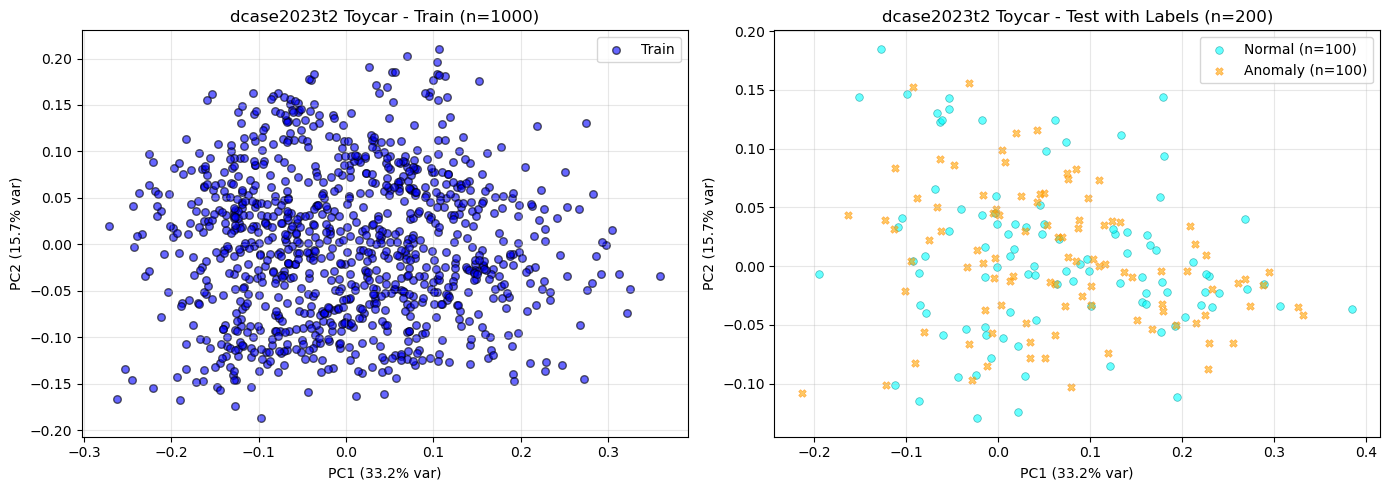

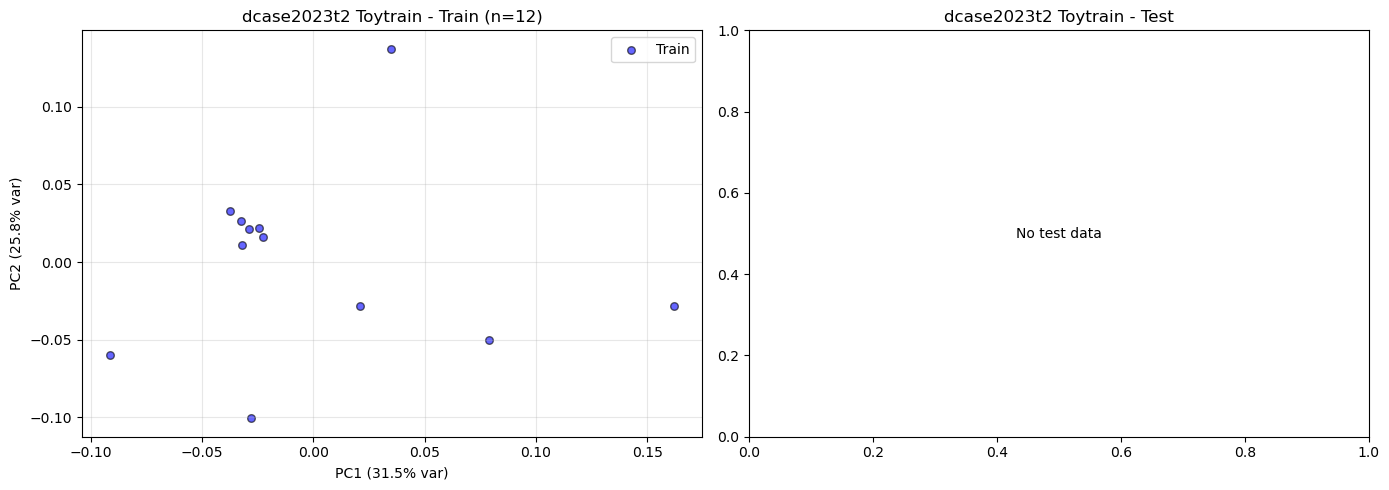

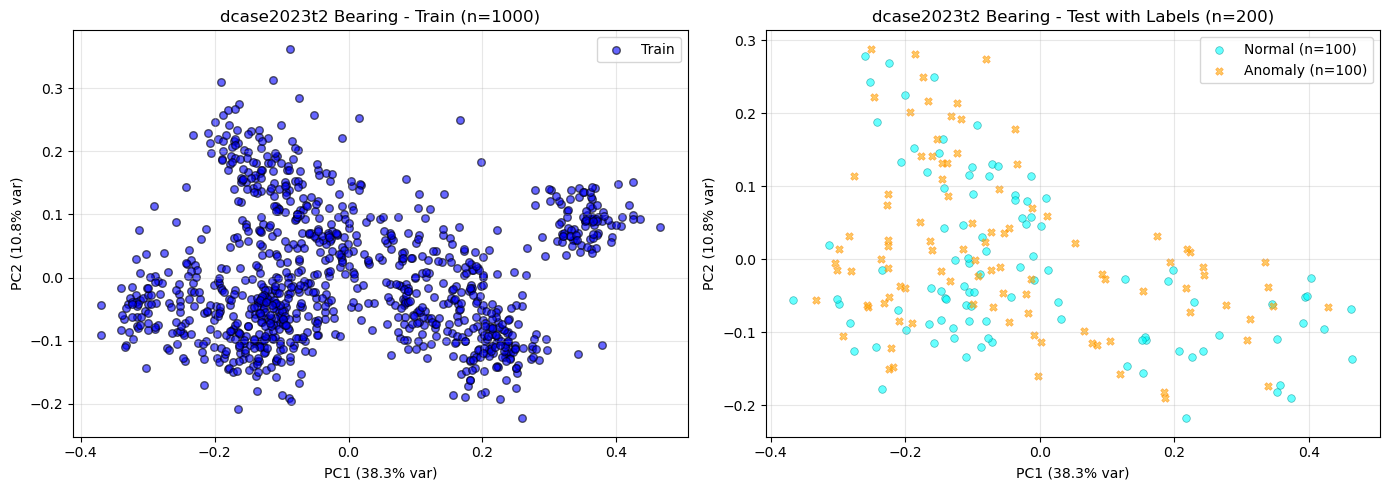

In [11]:
# Generate individual PCA scatterplots for each machine (train AND test)
import matplotlib.pyplot as plt
from config import iter_all_data, load_pca_results, get_test_features_path

def extract_label_from_filename(filename):
    """Extract 'normal' or 'anomaly' label from filename"""
    filename_lower = str(filename).lower()
    if 'anomaly' in filename_lower:
        return 1  # Anomaly
    elif 'normal' in filename_lower:
        return 0  # Normal
    else:
        return None  # Unknown label
    
for year, machine, _ in iter_all_data():
    X_train, variance_info_train = load_pca_results(model_used, year, machine, split="train")
    X_test, variance_info_test = load_pca_results(model_used, year, machine, split="test")
    
    if X_train is None and X_test is None:
        continue
    
    # Create figure with subplots for train and test
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Train subplot
    if X_train is not None:
        axs[0].scatter(X_train[:,0], X_train[:,1], alpha=0.6, s=30, color='blue', edgecolors='k', label='Train')
        axs[0].set_xlabel(f'PC1 ({variance_info_train["explained_variance_ratio"][0]:.1%} var)')
        axs[0].set_ylabel(f'PC2 ({variance_info_train["explained_variance_ratio"][1]:.1%} var)')
        axs[0].set_title(f'{year} {machine.title()} - Train (n={X_train.shape[0]})')
        axs[0].grid(True, alpha=0.3)
        axs[0].legend()
    else:
        axs[0].text(0.5, 0.5, 'No train data', ha='center', va='center')
        axs[0].set_title(f'{year} {machine.title()} - Train')
    
    # Test subplot
    if X_test is not None:
        # Extract labels from test filenames
        test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
        test_files = sorted(list(test_features_path.glob("**/*.npy")))
        
        test_labels = []
        for file in test_files:
            label = extract_label_from_filename(file.name)
            if label is not None:
                test_labels.append(label)
        
        # Color-code by labels if available
        if len(test_labels) == X_test.shape[0]:
            test_labels = np.array(test_labels)
            normal_mask = test_labels == 0
            anomaly_mask = test_labels == 1
            
            if np.sum(normal_mask) > 0:
                axs[1].scatter(X_test[normal_mask,0], X_test[normal_mask,1], alpha=0.6, s=30, 
                             color='cyan', edgecolors='darkcyan', linewidth=0.5, label=f'Normal (n={np.sum(normal_mask)})')
            if np.sum(anomaly_mask) > 0:
                axs[1].scatter(X_test[anomaly_mask,0], X_test[anomaly_mask,1], alpha=0.6, s=30,
                             color='orange', edgecolors='darkorange', linewidth=0.5, marker='X', label=f'Anomaly (n={np.sum(anomaly_mask)})')
        else:
            axs[1].scatter(X_test[:,0], X_test[:,1], alpha=0.6, s=30, color='red', edgecolors='k', label='Test')
        
        axs[1].set_xlabel(f'PC1 ({variance_info_test["explained_variance_ratio"][0]:.1%} var)')
        axs[1].set_ylabel(f'PC2 ({variance_info_test["explained_variance_ratio"][1]:.1%} var)')
        axs[1].set_title(f'{year} {machine.title()} - Test with Labels (n={X_test.shape[0]})')
        axs[1].grid(True, alpha=0.3)
        axs[1].legend()
    else:
        axs[1].text(0.5, 0.5, 'No test data', ha='center', va='center')
        axs[1].set_title(f'{year} {machine.title()} - Test')
    
    plt.tight_layout()
    plt.show()

In [12]:
from sklearn.neighbors import NearestNeighbors
import pickle
from pathlib import Path

class KNNAnomalyDetector:
    """
    KNN-based anomaly detection using distance to k-th nearest neighbor.
    - Training: Uses normal audio features to learn the data distribution
    - Detection: Points far from their neighbors (distance > threshold) are flagged as anomalies
    """
    
    def __init__(self, k=5, threshold_percentile=95):
        """
        Args:
            k: Number of nearest neighbors to use
            threshold_percentile: Percentile of training distances to use as threshold (default: 95th percentile)
        """
        self.k = k
        self.threshold_percentile = threshold_percentile
        self.knn = None
        self.threshold = None
        self.training_distances = None
        
    def fit(self, X_train):
        """
        Fit the detector on normal (training) data.
        Calculates distance to k-th neighbor and sets anomaly threshold.
        
        Args:
            X_train: Training features (n_samples, n_features) - should be normal data
        """
        
        # Fit KNN on training data
        self.knn = NearestNeighbors(n_neighbors=self.k+1)  # +1 because it includes the point itself
        self.knn.fit(X_train)
        
        # Get distances to k-th nearest neighbor for all training points
        distances, indices = self.knn.kneighbors(X_train)
        self.training_distances = distances[:, self.k]  # Distance to k-th neighbor (skip 1st which is self)
        
        # Set threshold based on percentile
        self.threshold = np.percentile(self.training_distances, self.threshold_percentile)

    def predict(self, X_test):
        """
        Predict anomalies for test data.
        
        Args:
            X_test: Test features (n_samples, n_features)
            
        Returns:
            predictions: Array of 0 (normal) or 1 (anomaly)
            distances: Distance to k-th nearest neighbor for each point
        """
        if self.knn is None:
            raise ValueError("Detector must be fitted first using .fit()")
        
        distances, _ = self.knn.kneighbors(X_test)
        test_distances = distances[:, self.k]  # Distance to k-th neighbor
        
        # Classify as anomaly if distance > threshold
        predictions = (test_distances > self.threshold).astype(int)
        
        return predictions, test_distances
    
    def predict_single(self, x):
        """Predict anomaly for a single sample"""
        predictions, distances = self.predict(x.reshape(1, -1))
        return predictions[0], distances[0]

from sklearn.metrics import (confusion_matrix, classification_report, 
                             precision_recall_fscore_support, roc_auc_score, 
                             roc_curve, auc, precision_recall_curve)
import matplotlib.pyplot as plt

def load_test_data_with_labels(year, machine):
    """Load PCA-reduced test features and extract labels from filenames"""
    # Load PCA-reduced test features
    pca_dir = get_pca_path(model_used, year, machine, dataset="dev")
    pca_test_file = pca_dir / "test_features_pca.npy"
    
    if not pca_test_file.exists():
        return None, None, None
    
    # Load PCA-reduced features
    X_test_pca = np.load(pca_test_file)
    
    # Get labels from raw test filenames
    test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
    if not test_features_path.exists():
        return None, None, None
    
    # Get all .npy files (in same order as they were processed)
    test_files = sorted(list(test_features_path.glob("**/*.npy")))
    if not test_files:
        return None, None, None
    
    # Extract labels from filenames
    labels = []
    file_labels = []
    
    for file in test_files:
        label = extract_label_from_filename(file.name)
        if label is not None:
            labels.append(label)
            file_labels.append((file.name, label))
    
    if not labels or len(labels) != X_test_pca.shape[0]:
        return None, None, None
    
    y_test = np.array(labels)
    
    return X_test_pca, y_test, file_labels

results_summary = []

for year, machine, _ in iter_all_data():
    # Load training data
    X_train, _ = load_pca_results(model_used, year, machine, split="train")
    if X_train is None:
        # print(f"⚠️  No train data available")
        continue
    
    # Load test data with labels
    X_test, y_test, file_labels = load_test_data_with_labels(year, machine)
    if X_test is None:
        # print(f"⚠️  No labeled test data available")
        continue
    
    # Train detector
    detector = KNNAnomalyDetector(k=5, threshold_percentile=95)
    detector.fit(X_train)
    
    # Make predictions
    predictions, distances = detector.predict(X_test)
    
    # Compute metrics
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, predictions, average='binary')
    
    # ROC-AUC using distances (lower distance = more normal)
    y_scores = 1 - (distances / distances.max())  # Normalize distances to [0,1]
    roc_auc = roc_auc_score(y_test, y_scores)

    # Store results for summary
    results_summary.append({
        'machine': f"{year}-{machine}",
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'test_samples': X_test.shape[0]
    })
    
if results_summary:
    print(f"\n\n{'='*100}")
    print("SUMMARY: Performance Across All Machines")
    print(f"{'='*100}")
    print(f"{'Machine':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'ROC-AUC':<12} {'Samples':<10}")
    print(f"{'-'*100}")
    for result in results_summary:
        print(f"{result['machine']:<20} {result['precision']:<12.4f} {result['recall']:<12.4f} "
              f"{result['f1']:<12.4f} {result['roc_auc']:<12.4f} {result['test_samples']:<10}")
    print(f"{'-'*100}")
    avg_f1 = np.mean([r['f1'] for r in results_summary])
    avg_auc = np.mean([r['roc_auc'] for r in results_summary])
    print(f"{'Average':<20} {np.mean([r['precision'] for r in results_summary]):<12.4f} "
          f"{np.mean([r['recall'] for r in results_summary]):<12.4f} {avg_f1:<12.4f} {avg_auc:<12.4f}")
    print(f"{'='*100}")




SUMMARY: Performance Across All Machines
Machine              Precision    Recall       F1-Score     ROC-AUC      Samples   
----------------------------------------------------------------------------------------------------
dcase2023t2-ToyCar   0.4390       0.1800       0.2553       0.4848       200       
dcase2023t2-bearing  0.6226       0.3300       0.4314       0.4117       200       
----------------------------------------------------------------------------------------------------
Average              0.5308       0.2550       0.3433       0.4483      
